#Session 02 - NIT 6004 - Neural Network and Deep Learning



In [2]:
import tensorflow as tf
import numpy as np

a = tf.constant([-20, -1.0, 0.0, 1.0, 20], dtype = tf.float32)
b = tf.keras.activations.sigmoid(a)

b.numpy()

array([2.0611537e-09, 2.6894143e-01, 5.0000000e-01, 7.3105860e-01,
       1.0000000e+00], dtype=float32)

In [3]:
b = tf.keras.activations.tanh(a)

b.numpy()

array([-1.       , -0.7615942,  0.       ,  0.7615942,  1.       ],
      dtype=float32)

In [9]:
foo = tf.constant([-10, -5, 0.0, 5, 10], dtype = tf.float32)
tf.keras.activations.relu(foo).numpy()

# Got Error
# tf.keras.activations.relu(foo, alpha=0.5).numpy()

# Instead of tf.keras.activations.relu
tf.nn.leaky_relu(foo, alpha=0.5).numpy()

tf.keras.activations.relu(foo, max_value = 5).numpy()

tf.keras.activations.relu(foo, threshold = 5).numpy()

array([-0., -0.,  0.,  0., 10.], dtype=float32)

In [11]:
layer = tf.keras.layers.Dense(32, activation=tf.keras.activations.softmax)

In [10]:
inputs = tf.random.normal(shape=(32, 10))
outputs = tf.keras.activations.softmax(inputs)
tf.reduce_sum(outputs[0, :])


<tf.Tensor: shape=(), dtype=float32, numpy=1.0>

**TASK**

**Step 1: Load Tensorflow, tf.keras and libraries**

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.19.0


**Step 2: Keras function to import Fashion MNIST dataset**

In [16]:
from keras.datasets import fashion_mnist

(X_train_full, Y_train_full), (X_test, Y_test) = fashion_mnist.load_data()

**Step 3: Classnames**

In [17]:
class_names = ["T-shirt/top",
"Trouser", "Pullover", "Dress", "Coat" ,
"Sandal",
"shirt", "Sneaker",
"Bag", "Ankle boot" ]

**Step 4: Explore dataset**

In [18]:
print(X_train_full.shape)
print(Y_train_full.shape)

print(X_test.shape)
print(Y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


**Step 5: Preprocess Data**

<function matplotlib.pyplot.show(close=None, block=None)>

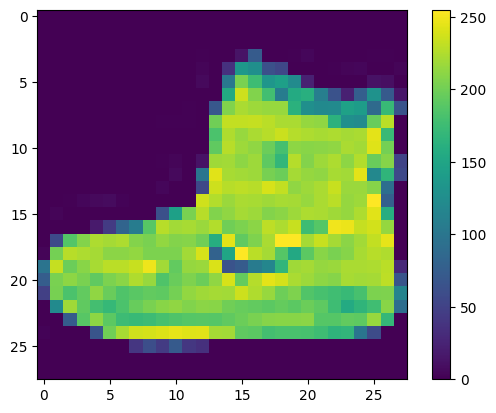

In [19]:
plt.figure()
plt.imshow(X_train_full[0])
plt.colorbar()
plt.grid(False)
plt.show

In [22]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
Y_valid, Y_train = Y_train_full[:5000], Y_train_full[5000: ]
x_test = x_test / 255.0

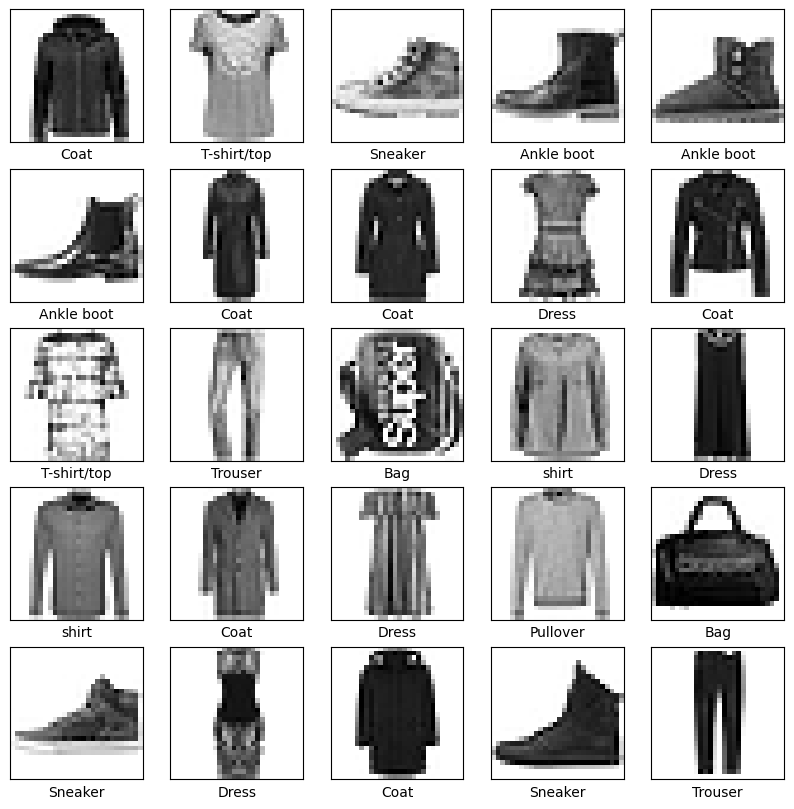

In [30]:
plt.figure(figsize = (10, 10))
for i in range(25):
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(X_train[i], cmap = plt.cm.binary)
  plt.xlabel(class_names[Y_train[i]])
plt.show()

In [31]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(loss = "sparse_categorical_crossentropy", optimizer = "sgd", metrics = ["accuracy"])

In [35]:
history = model.fit(X_train, Y_train, epochs = 30, validation_data = (X_valid, Y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6784 - loss: 0.9964 - val_accuracy: 0.8230 - val_loss: 0.5234
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8248 - loss: 0.5064 - val_accuracy: 0.8454 - val_loss: 0.4500
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8429 - loss: 0.4494 - val_accuracy: 0.8552 - val_loss: 0.4193
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8513 - loss: 0.4238 - val_accuracy: 0.8622 - val_loss: 0.4072
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8630 - loss: 0.3950 - val_accuracy: 0.8540 - val_loss: 0.4060
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8651 - loss: 0.3827 - val_accuracy: 0.8678 - val_loss: 0.3765
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8725 - loss: 0.3611 - val_accuracy: 0.8728 - val_loss: 0.3688
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8716 - loss: 0.3623 -

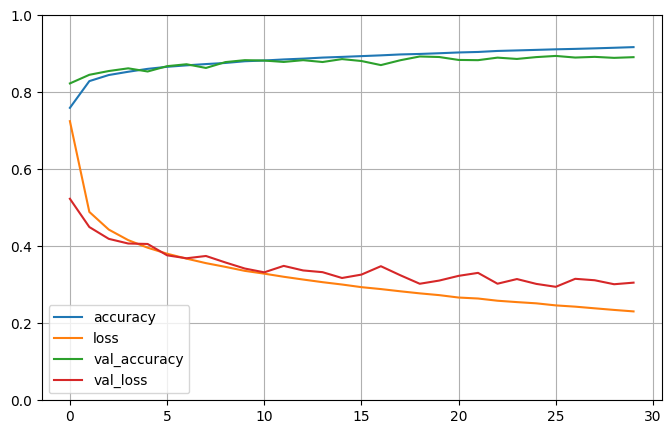

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize = (8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [37]:
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=2)
print('\n Test Accuracy: ', test_acc)
print('\n Test Loss: ', test_loss)


313/313 - 1s - 2ms/step - accuracy: 0.8153 - loss: 83.8467

 Test Accuracy:  0.8152999877929688

 Test Loss:  83.84668731689453


In [38]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(X_test)
predictions[0]

np.argmax(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


np.int64(9)

In [42]:
Y_test[0]

np.uint8(9)